# Advanced Performance

`PauliPropagation.jl` is designed to be modular, extensible, and easy to use at a high level. At the same time, we want to enable state-of-the-art Pauli propagation performance. This is a notebook explaining how to squeeze the most out of this library. We change one thing at a time on one and the same example circuit, so that you can see what every step is worth.

In [1]:
using Pkg
Pkg.activate(".")
using PauliPropagation
using PauliPropagation.Performance
using Base.Threads
using Printf
using Plots

println("Threads.nthreads() = $(nthreads())")
println("Note thread-count and timings may vary based on the machine this notebook is run on.")

  Activating 

Threads.nthreads() = 8


project at `~/Projects/PauliPropagation.jl/examples`


Note thread-count and timings may vary based on the machine this notebook is run on.


## A $6\times6$ tilted-field Ising circuit

We consider the example quantum circuits that corresponds to the Trotterized dynamics of a $6\times6$ tilted-field Ising Hamiltonian. One Trotter layer consists of single-qubit $R_x$ and $R_z$ rotations plus nearest-neighbour $R_{zz}$ rotations. The observable is $Z_{21}Z_{22}$ sitting right in the middle of the grid.

In [2]:
nx = 6
ny = 6
nq = nx * ny

dt = 0.05
h = 1.0
J = 0.5

topology = rectangletopology(nx, ny)
layer = PauliRotation[]
rxlayer!(layer, nq)
rzlayer!(layer, nq)
rzzlayer!(layer, topology)

thetas = ones(countparameters(layer)) * dt * 2

x_inds = getparameterindices(layer, PauliRotation, [:X])
z_inds = getparameterindices(layer, PauliRotation, [:Z])
zz_inds = getparameterindices(layer, PauliRotation, [:Z, :Z])
thetas[x_inds] .*= h
thetas[z_inds] .*= h
thetas[zz_inds] .*= J

pstr = PauliString(nq, [:Z, :Z], [21, 22])
min_abs_coeff = 2.0^(-20)

nlayers = 14;

## Switching to `VectorPauliSum`
Most of our examples use the `PauliSum` type, which stores Pauli strings and their coefficients in a `Dict`. It is flexible and generally a robust choice. Our first performance suggestion is to switch to `VectorPauliSum`, which stores Pauli strings and their coefficients in two `Vector`s. This is generally faster for non-branching gates such as `CliffordGate` and `DepolarizingNoise`, but we also have optimized code for the very common `PauliRotation` gate.

Let us run all 14 layers with either type. The `PauliSum` run is slow enough that we time it once, compiling the code on one layer up front so that the timing does not carry the compilation. Every other configuration in this notebook first runs the propagation once as written, which is also what gives us the Pauli sum to look at, and then times the fastest of a few repetitions, so that growing the arrays to their final size for the first time stays out of the number.

In [3]:
circuit = repeat(layer, nlayers)
circuit_thetas = repeat(thetas, nlayers)

nreps = 3

function besttime(f::F) where {F}
    t = Inf
    for _ in 1:nreps
        GC.gc()
        t = min(t, @elapsed f())
    end
    return t
end

besttime (generic function with 1 method)

In [4]:
# one layer up front, so that the single run below does not carry the compilation
propagate(layer, PauliSum(pstr), thetas; min_abs_coeff)

t_dict = @elapsed dict_psum = propagate(circuit, PauliSum(pstr), circuit_thetas; min_abs_coeff)

vec_psum = propagate(circuit, VectorPauliSum(pstr), circuit_thetas; min_abs_coeff)

t_vec = besttime(() -> propagate(circuit, VectorPauliSum(pstr), circuit_thetas; min_abs_coeff))

@printf("PauliSum:        %5.2f s   (%d Pauli terms)\n", t_dict, length(dict_psum))
@printf("VectorPauliSum:  %5.2f s   (%d Pauli terms)\n", t_vec, length(vec_psum))

PauliSum:        10.13 s   (1036142 Pauli terms)
VectorPauliSum:   2.37 s   (1036142 Pauli terms)


Both give the same expectation value $\langle Z_{21} Z_{22}\rangle$.

In [5]:
overlapwithzero(dict_psum), overlapwithzero(vec_psum)

(0.6696851623009783, 0.6696851623009762)

## Fused kernels in `PauliPropagation.Performance`

The default propagation applies a gate to all Pauli strings, then merges the duplicates, then truncates, each as its own pass over the Pauli sum. We maintain this modularity so users can easily hook into it and extend the library. `PauliPropagation.Performance` is an opt-in module whose kernels fold those steps into fewer passes over a `VectorPauliSum`, which saves the memory traffic in between but is harder to extend. It brings its own `propagate` and `propagate!` with the same signatures, so all you have to do is qualify the call.

These kernels are somewhat experimental, and their coefficients can differ from the default ones in the last digits. Please report any issues you encounter via the issue tracker. Passing `fused=false` falls back to the default behavior.

In [6]:
fused_psum = Performance.propagate(circuit, VectorPauliSum(pstr), circuit_thetas; min_abs_coeff)

t_fused = besttime(() -> Performance.propagate(circuit, VectorPauliSum(pstr), circuit_thetas; min_abs_coeff))

@printf("Performance.propagate:  %5.2f s   (%d Pauli terms)\n", t_fused, length(fused_psum))
@printf("⟨Z21 Z22⟩ = %.14f  vs  %.14f\n", overlapwithzero(fused_psum), overlapwithzero(vec_psum))

Performance.propagate:   0.93 s   (1036142 Pauli terms)
⟨Z21 Z22⟩ = 0.66968516230098  vs  0.66968516230098


## Threading

Every run so far was multi-threaded, which is the default. `thread=false` forces a single-threaded propagation. Threading here means splitting one gate application across all threads, so it only pays off once the Pauli sum is large enough that the work per task outweighs the cost of spawning the tasks. Even at a million Pauli terms the return is modest, and on a smaller example or a busier machine it can just as well come out negative. The `MultiPauliSum` below threads differently and does better at all sizes.

Threading is also the wrong choice if you already parallelize at a higher level, because the nested tasks would only compete for the same cores.

In [7]:
t_serial = besttime(() -> Performance.propagate(circuit, VectorPauliSum(pstr), circuit_thetas; min_abs_coeff, thread=false))

@printf("thread=false:  %5.2f s\n", t_serial)
@printf("thread=true:   %5.2f s\n", t_fused)

thread=false:   0.92 s
thread=true:    0.93 s


## Splitting the sum over work zones with `MultiPauliSum`

Threading has so far meant many threads working on one Pauli sum together. `MultiPauliSum` takes the other route and splits the sum into work zones, each of them an ordinary Pauli sum that a single thread owns. Every Pauli string belongs to exactly one zone, so the threads never write into each other's zones and the zones never have to coordinate. The parallelism comes from the zones themselves rather than from splitting every gate application across threads.

A zone keeps the Pauli sum type it was split from, so splitting a `VectorPauliSum` and propagating it with `Performance.propagate` runs the fused kernels inside every zone. By default the sum is split over one zone per thread if the number of threads is a power of two, and over twice the next power of two otherwise, where an even split would leave threads idle.

In [8]:
zone_psum = Performance.propagate(circuit, MultiPauliSum(VectorPauliSum(pstr)), circuit_thetas; min_abs_coeff)

t_zones = besttime(() -> Performance.propagate(circuit, MultiPauliSum(VectorPauliSum(pstr)), circuit_thetas; min_abs_coeff))

@printf("MultiPauliSum over %d zones:  %5.2f s   (%d Pauli terms)\n", nzones(zone_psum), t_zones, length(zone_psum))
@printf("⟨Z21 Z22⟩ = %.14f  vs  %.14f\n", overlapwithzero(zone_psum), overlapwithzero(vec_psum))

MultiPauliSum over 8 zones:   0.54 s   (1036142 Pauli terms)
⟨Z21 Z22⟩ = 0.66968516230098  vs  0.66968516230098


## Sizing the scratch space up front with `resize!`

Underneath, propagation works in a `PropagationCache`: a main and an auxiliary Pauli sum, plus a few helper arrays. Set up for us, it starts out at the size of our one-term input and grows along with the Pauli sum, which means repeatedly asking for more memory and copying over what is already there. If we build that cache ourselves, we can size it up front and hand it to `propagate!`.

`resize!(prop_cache, N)` grows all of its arrays once, with `N` a generous estimate of the largest number of Pauli terms the run will reach. Estimating too high only costs memory, and estimating too low simply leaves the remaining growing to the arrays themselves.

In [9]:
resized_cache = PropagationCache(MultiPauliSum(VectorPauliSum(pstr)))
resize!(resized_cache, 1_500_000)
Performance.propagate!(circuit, resized_cache, circuit_thetas; min_abs_coeff)

t_resize = besttime() do
    pc = PropagationCache(MultiPauliSum(VectorPauliSum(pstr)))
    resize!(pc, 1_500_000)
    Performance.propagate!(circuit, pc, circuit_thetas; min_abs_coeff)
end

@printf("resize!d cache:  %5.2f s   (%d Pauli terms)\n", t_resize, length(resized_cache))
@printf("⟨Z21 Z22⟩ = %.14f  vs  %.14f\n", overlapwithzero(resized_cache), overlapwithzero(vec_psum))

resize!d cache:   0.50 s   (1036142 Pauli terms)
⟨Z21 Z22⟩ = 0.66968516230098  vs  0.66968516230098


## Before and after

Let us count how many Paulis we work through per second with what we have so far. Every row keeps the changes of the rows above it.

In [10]:
# the number of Pauli terms each layer starts from, to count gate applications
counts = Int[]
count_msum = MultiPauliSum(VectorPauliSum(pstr))
for l in 1:nlayers
    push!(counts, length(count_msum))
    Performance.propagate!(layer, count_msum, thetas; min_abs_coeff)
end

napplied = length(layer) * sum(counts)

labels = ["PauliSum", "VectorPauliSum", "+ Performance\nfused", "+ MultiPauliSum\nzones", "+ resize!\nup front"]
times = [t_dict, t_vec, t_fused, t_zones, t_resize]
rates = napplied ./ times ./ 1e6

@printf("%d gate applications on Pauli strings in total\n\n", napplied)
for (l, t, r) in zip(labels, times, rates)
    @printf("%-28s %6.2f s   %6.1f M Paulis/s\n", replace(l, "\n" => " "), t, r)
end

200640660 gate applications on Pauli strings in total

PauliSum                      10.13 s     19.8 M Paulis/s
VectorPauliSum                 2.37 s     84.6 M Paulis/s
+ Performance fused            0.93 s    216.5 M Paulis/s
+ MultiPauliSum zones          0.54 s    372.0 M Paulis/s
+ resize! up front             0.50 s    403.2 M Paulis/s


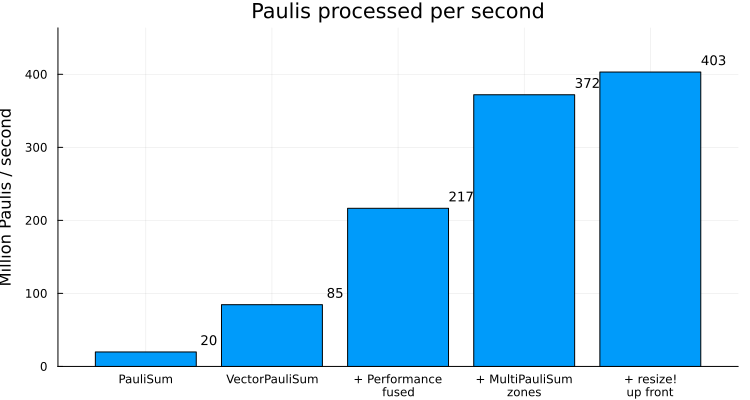

In [11]:
p = bar(labels, rates, legend=false, ylabel="Million Paulis / second", size=(750, 400),
    ylims=(0, 1.15 * maximum(rates)), title="Paulis processed per second")
annotate!(p, 1:length(rates), rates .+ 0.04 * maximum(rates), [text(@sprintf("%.0f", r), 9) for r in rates])
p

## Propagating layer by layer with `propagate!`

Everything so far handed the whole circuit over in one call. But a Trotterized time evolution applies the same layer over and over, and usually wants an expectation value after every step. `propagate!` advances one Pauli sum through one layer at a time, in place, so that we can read the observable off it in between.

This is a different thing to measure rather than another step up, which is why the plot above stops where it does. What stopping after every layer costs depends on how much work one layer is, and a layer of this circuit applies well over a hundred gates, so here it barely shows. The two sections after this one apply the same two ideas to the layer-by-layer loop, and a second plot at the end compares the three.

In [12]:
zone_msum = MultiPauliSum(VectorPauliSum(pstr))
expectations = Float64[]

for l in 1:nlayers
    Performance.propagate!(layer, zone_msum, thetas; min_abs_coeff)
    push!(expectations, overlapwithzero(zone_msum))
end

t_inplace = besttime() do
    msum = MultiPauliSum(VectorPauliSum(pstr))
    for l in 1:nlayers
        Performance.propagate!(layer, msum, thetas; min_abs_coeff)
    end
end

@printf("propagate! layer by layer:  %5.2f s   (%d Pauli terms)\n", t_inplace, length(zone_msum))

propagate! layer by layer:   0.59 s   (1036142 Pauli terms)


The expectation values we collected along the way give us the whole time series.

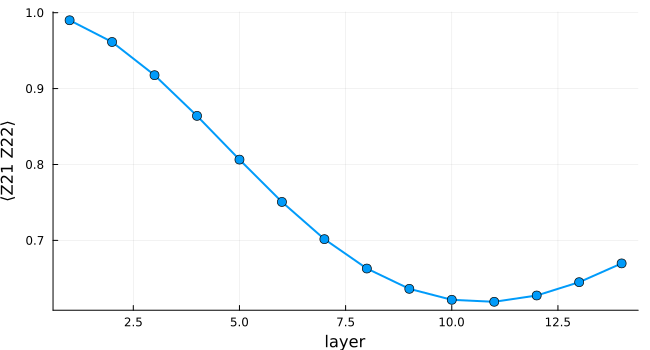

In [13]:
plot(1:nlayers, expectations, xlabel="layer", ylabel="⟨Z21 Z22⟩", legend=false,
    linewidth=2, marker=:circle, markersize=5, size=(650, 350))

## Reusing the scratch space with `PropagationCache`

Every one of those 14 `propagate!` calls sets up its own cache internally and throws it away again afterwards. Handing `propagate!` a `PropagationCache` of our own keeps it alive across the layers instead. Every call writes into the auxiliary sum and then swaps the two, so nothing has to be allocated in between. There is not much to win here, because one layer of this circuit applies well over a hundred gates and the setup happens once per layer, but the shorter the layers the more it weighs.

Expectation values can be read straight off the cache with `overlapwithzero(prop_cache)`, without extracting a Pauli sum.

In [14]:
prop_cache = PropagationCache(MultiPauliSum(VectorPauliSum(pstr)))

for l in 1:nlayers
    Performance.propagate!(layer, prop_cache, thetas; min_abs_coeff)
end

t_cache = besttime() do
    pc = PropagationCache(MultiPauliSum(VectorPauliSum(pstr)))
    for l in 1:nlayers
        Performance.propagate!(layer, pc, thetas; min_abs_coeff)
    end
end

@printf("propagate! into a cache:  %5.2f s   (%d Pauli terms)\n", t_cache, length(prop_cache))
@printf("⟨Z21 Z22⟩ = %.14f  vs  %.14f\n", overlapwithzero(prop_cache), expectations[end])

propagate! into a cache:   0.50 s   (1036142 Pauli terms)
⟨Z21 Z22⟩ = 0.66968516230098  vs  0.66968516230098


## Sizing that cache up front too

`resize!` applies here just as it did further above. The cache we carry from one layer to the next can start at its final size instead of growing into it.

In [15]:
layer_resized_cache = PropagationCache(MultiPauliSum(VectorPauliSum(pstr)))
resize!(layer_resized_cache, 1_500_000)

for l in 1:nlayers
    Performance.propagate!(layer, layer_resized_cache, thetas; min_abs_coeff)
end

t_layer_resize = besttime() do
    pc = PropagationCache(MultiPauliSum(VectorPauliSum(pstr)))
    resize!(pc, 1_500_000)
    for l in 1:nlayers
        Performance.propagate!(layer, pc, thetas; min_abs_coeff)
    end
end

@printf("resize!d cache, layer by layer:  %5.2f s   (%d Pauli terms)\n", t_layer_resize, length(layer_resized_cache))
@printf("⟨Z21 Z22⟩ = %.14f  vs  %.14f\n", overlapwithzero(layer_resized_cache), expectations[end])

resize!d cache, layer by layer:   0.48 s   (1036142 Pauli terms)
⟨Z21 Z22⟩ = 0.66968516230098  vs  0.66968516230098


## Before and after, layer by layer

The same count once more, for the three ways of walking the circuit one layer at a time. The scale is the one of the plot above, so the two can be read against each other.

In [16]:
layer_labels = ["propagate!\nlayer by layer", "+ Propagation\nCache", "+ resize!\nup front"]
layer_times = [t_inplace, t_cache, t_layer_resize]
layer_rates = napplied ./ layer_times ./ 1e6

for (l, t, r) in zip(layer_labels, layer_times, layer_rates)
    @printf("%-28s %6.2f s   %6.1f M Paulis/s\n", replace(l, "\n" => " "), t, r)
end

propagate! layer by layer      0.59 s    337.5 M Paulis/s
+ Propagation Cache            0.50 s    398.1 M Paulis/s
+ resize! up front             0.48 s    418.3 M Paulis/s


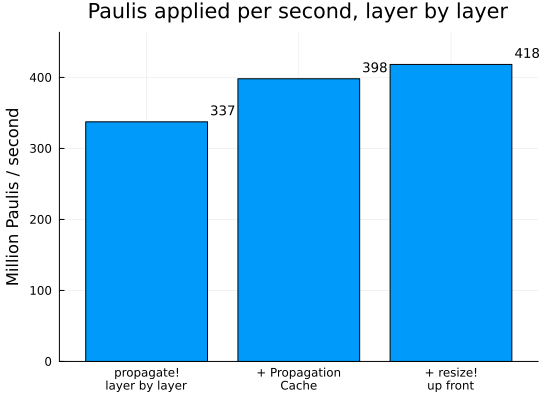

In [17]:
p = bar(layer_labels, layer_rates, legend=false, ylabel="Million Paulis / second", size=(550, 400),
    ylims=(0, 1.15 * maximum(rates)), title="Paulis applied per second, layer by layer")
annotate!(p, 1:length(layer_rates), layer_rates .+ 0.04 * maximum(rates), [text(@sprintf("%.0f", r), 9) for r in layer_rates])
p

## Not all gates cost the same

A `PauliRotation` only branches the Pauli strings that anticommute with its generator, and leaves the rest untouched. What a gate costs therefore depends on where it sits. Take the Pauli sum after all 14 layers and apply a single $R_{zz}$ rotation to it, once at a corner of the grid and once in the middle where the observable lives. In the middle, a good fraction of the sum branches; at the corner, the few branches that appear fall below `min_abs_coeff` right away.

We take the `VectorPauliSum` from the fused run further above, so that we time one gate on one Pauli sum rather than the same gate spread over the zones.

In [18]:
snapshot = fused_psum
n = length(snapshot)
theta = 2 * dt * J

edge_gate = PauliRotation([:Z, :Z], [1, 2])
mid_gate = PauliRotation([:Z, :Z], [21, 22])

edge_cache = PropagationCache(deepcopy(snapshot))
resize!(edge_cache, 2n)
Performance.propagate!(edge_gate, edge_cache, theta; min_abs_coeff)

mid_cache = PropagationCache(deepcopy(snapshot))
resize!(mid_cache, 2n)
Performance.propagate!(mid_gate, mid_cache, theta; min_abs_coeff)

# a fresh cache per run, set up outside the timed region
function gatetime(gate)
    t = Inf
    for _ in 1:nreps
        pc = PropagationCache(deepcopy(snapshot))
        resize!(pc, 2n)
        GC.gc()
        t = min(t, @elapsed Performance.propagate!(gate, pc, theta; min_abs_coeff))
    end
    return t
end

t_edge = gatetime(edge_gate)
t_mid = gatetime(mid_gate)

@printf("Rzz on qubits (1, 2):    %5.0f M Paulis/s   (%d -> %d terms)\n", n / t_edge / 1e6, n, length(edge_cache))
@printf("Rzz on qubits (21, 22):  %5.0f M Paulis/s   (%d -> %d terms)\n", n / t_mid / 1e6, n, length(mid_cache))

Rzz on qubits (1, 2):     1952 M Paulis/s   (1036142 -> 1036142 terms)
Rzz on qubits (21, 22):    205 M Paulis/s   (1036142 -> 1047250 terms)


## Summary

Switch to `VectorPauliSum` once your Pauli sums reach hundreds of thousands of terms, and reach for the fused kernels in `PauliPropagation.Performance` if you need to squeeze out all the performance this library has to offer. Let them thread unless you are already parallelizing somewhere above, split the sum into work zones with `MultiPauliSum`, which is the parallelism that scales best here, and hand `propagate!` a `PropagationCache` that you have `resize!`d to the size you expect. For layered evolution, advance that same cache one layer at a time and estimate the observables off it in between, which costs a little throughput and gives you the whole time series.